### Building Chatbot With Multiple Tools Using Langgraph

#### Aim
Create a chatbot with tool capabilities from arxiv, wikipedia search and some functions

In [5]:
from langchain_community.tools import ArxivQueryRun,WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper,ArxivAPIWrapper

In [7]:
import arxiv as arxiv_lib
# Patch arxiv 2.x+ / 4.x compatibility for LangChain
if not hasattr(arxiv_lib.Search, 'results'):
    arxiv_lib.Search.results = lambda self: arxiv_lib.Client().results(self)

In [8]:
api_wrapper_arxiv=ArxivAPIWrapper(top_k_results=2,doc_content_chars_max=500)
arxiv=ArxivQueryRun(api_wrapper=api_wrapper_arxiv)
print(arxiv.name)

arxiv


In [9]:
arxiv.invoke("Attention iss all you need")

'Published: 2021-05-06\nTitle: Do You Even Need Attention? A Stack of Feed-Forward Layers Does Surprisingly Well on ImageNet\nAuthors: Luke Melas-Kyriazi\nSummary: The strong performance of vision transformers on image classification and other vision tasks is often attributed to the design of their multi-head attention layers. However, the extent to which attention is responsible for this strong performance remains unclear. In this short report, we ask: is the attention layer even necessary? Specifi'

In [14]:
import wikipedia
wikipedia.set_user_agent("MyLangChainApp/1.0 (contact@example.com)")

In [15]:
api_wrapper_wiki=WikipediaAPIWrapper(top_k_results=1,doc_content_chars_max=500)
wiki=WikipediaQueryRun(api_wrapper=api_wrapper_wiki)
wiki.name

'wikipedia'

In [16]:
wiki.invoke("What is machine learning")

'Page: Machine learning\nSummary: Machine learning (ML) is a field of study in artificial intelligence concerned with the development and study of statistical algorithms that can learn from  data and generalize to unseen data, and thus perform tasks without being explicitly programmed. Advances in the field of deep learning have allowed neural networks, a class of statistical algorithms, to surpass many previous machine learning approaches in performance.\nStatistics and mathematical optimisation m'

In [17]:
from dotenv import load_dotenv
load_dotenv()

import os

os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")



In [18]:
### Tavily Search Tool
from langchain_community.tools.tavily_search import TavilySearchResults

tavily = TavilySearchResults()

C:\Users\DELL\AppData\Local\Temp\ipykernel_15644\3584238.py:4: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily = TavilySearchResults()


In [19]:
tavily.invoke("Provide me the recent AI news for march 3rd 2025")

[{'title': 'March 2025 - The Artificial Intelligence Revolution',
  'url': 'https://choreoadvisors.com/market-perspectives/march-2025-the-artificial-intelligence-revolution',
  'content': 'There are plenty of signs that AI is beginning to have a material effect on the world. One of the early signals may be the valuation of AI-related private companies such as OpenAI. Investors are willing to pay up for what they believe could be a potential leader in the field. The ChatGPT maker’s most recent funding round in the private markets valued the company at $300 billion. At current markets as of 3/3/25, this would place it as the 27th largest company in the S&P 500, a staggering valuation for a private entity. [...] There are risks abounding in the technology itself and the rapidly evolving investment landscape surrounding AI. Often with new technology, the initial spend is high as an arms race of sorts ensues. Also of note, the first companies and technology paths are often not the ultimate 

In [20]:
### Combine all the tools in the list

tools=[arxiv,wiki,tavily]

In [21]:
## Initialize my LLM model

from langchain_groq import ChatGroq

llm=ChatGroq(model="qwen/qwen3.6-27b")

llm_with_tools=llm.bind_tools(tools)

In [22]:
from pprint import pprint
from langchain_core.messages import AIMessage, HumanMessage
llm_with_tools.invoke([HumanMessage(content=f"What is the recent AI News")])

AIMessage(content='', additional_kwargs={'reasoning_content': "I will first search for the latest news related to Artificial Intelligence using a general search engine.\nFinally, I will answer the user's request about recent AI news based on the search results.\n", 'tool_calls': [{'id': 'g5p6yewcv', 'function': {'arguments': '{"query":"recent AI News"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 72, 'prompt_tokens': 521, 'total_tokens': 593, 'completion_time': 0.138594432, 'completion_tokens_details': {'reasoning_tokens': 39}, 'prompt_time': 0.038347942, 'prompt_tokens_details': None, 'queue_time': 0.045397207, 'total_time': 0.176942374}, 'model_name': 'qwen/qwen3.6-27b', 'system_fingerprint': 'fp_49d6b1859d', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a05daf-e0fa-74b2-905c-761e5276737d-0', tool_calls=[{'name': 'tavily_search_results_js

In [23]:
llm_with_tools.invoke([HumanMessage(content=f"What is the recent AI News")]).tool_calls

[{'name': 'tavily_search_results_json',
  'args': {'query': 'latest artificial intelligence news today'},
  'id': 'p5sgd6j8x',
  'type': 'tool_call'}]

In [24]:
## State Schema
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage
from typing import Annotated
from langgraph.graph.message import add_messages
class State(TypedDict):
    messages:Annotated[list[AnyMessage],add_messages]

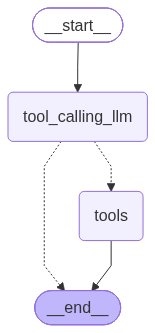

In [25]:
### Entire Chatbot With LangGraph
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

### Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

# Build graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition,
)
builder.add_edge("tools", END)


graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))


In [26]:
messages=graph.invoke({"messages":HumanMessage(content="1706.03762")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

1706.03762
================================== Ai Message ==================================
Tool Calls:
  arxiv (fsm7gap64)
 Call ID: fsm7gap64
  Args:
    query: 1706.03762
================================= Tool Message =================================
Name: arxiv

Published: 2023-08-02
Title: Attention Is All You Need
Authors: Ashish Vaswani, Noam Shazeer, Niki Parmar, Jakob Uszkoreit, Llion Jones, Aidan N. Gomez, Lukasz Kaiser, Illia Polosukhin
Summary: The dominant sequence transduction models are based on complex recurrent or convolutional neural networks in an encoder-decoder configuration. The best performing models also connect the encoder and decoder through an attention mechanism. We propose a new simple network architecture, the Transformer, base


In [27]:
messages=graph.invoke({"messages":HumanMessage(content="Provide me the top 10 recent AI news for MArch 3rd 2025")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Provide me the top 10 recent AI news for MArch 3rd 2025
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (6s5d0z0xj)
 Call ID: 6s5d0z0xj
  Args:
    query: top AI news March 3rd 2025
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "Top 5 AI trends in March 2025: AI agents, smarter supply ...", "url": "https://www.neudesic.com/blog/top-5-ai-trends-march-2025", "content": "Below, we delve into five top AI trends from March 2025 and explore the practical ways they’re changing industries—from retail to robotics—and setting the stage for what’s ahead. \n\n## 1. OpenAI Releases New Tools for Building AI Agents\n\nOpenAI released a suite of tools aimed at helping developers and enterprises build useful and reliable AI agents. These tools include the Responses API 

In [28]:
messages=graph.invoke({"messages":HumanMessage(content="What is machine learning")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

What is machine learning
================================== Ai Message ==================================

In simple terms, **Machine Learning (ML)** is a branch of Artificial Intelligence (AI) that gives computers the ability to learn from data without being explicitly programmed for every specific task.

Instead of writing code that tells a computer exactly how to solve a problem (e.g., "If X happens, do Y"), machine learning provides the computer with vast amounts of data and lets it figure out the rules on its own to make predictions or decisions.

Here is a breakdown of how it works, the different types, and where you see it.

---

### 1. How It Works (The Concept)
Imagine you want to teach a computer to recognize a cat.

*   **Traditional Programming:** You would have to write thousands of lines of code describing a cat (e.g., "has whiskers," "pointy ears," "fur," "meows"). If the cat is upside down